# Cluster analysis

# Import necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from scipy.spatial.distance import pdist

from scipy.cluster.hierarchy import linkage, dendrogram

from scipy.cluster.hierarchy import centroid, ward

from scipy.cluster.hierarchy import fcluster

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load dataset

In [2]:
maize_data_cluster = pd.read_csv('maize_data_cluster.csv')
maize_data_cluster.head()

,Genotypes,PH,EH,KPR,CG,CL,CW,1000K
0,IGI-19-23,167.8,83.70,21.47,10.73,11.70,39.80,240.00
1,IGI-19-24,150.2,50.25,26.20,10.68,13.45,50.40,243.33
2,IGI-19-25,124.0,42.86,12.53,10.44,10.75,33.87,186.67
3,IGI-19-26,168.4,96.37,31.27,11.88,16.35,87.33,273.33
4,IGI-19-27,150.8,72.53,18.93,11.08,12.68,53.47,213.33


In [3]:
# select the dataframe for cluster analysis
data = maaize_data_cluster.iloc[:, 1:8]
data.head()

,PH,EH,KPR,CG,CL,CW,1000K
0,167.8,83.70,21.47,10.73,11.70,39.80,240.00
1,150.2,50.25,26.20,10.68,13.45,50.40,243.33
2,124.0,42.86,12.53,10.44,10.75,33.87,186.67
3,168.4,96.37,31.27,11.88,16.35,87.33,273.33
4,150.8,72.53,18.93,11.08,12.68,53.47,213.33


In [4]:
# Assign cluster labels from dataset
d = maize_data_cluster.iloc[:, 0]

# Distance measures

In [5]:
# Compute pairwise Euclidean distances between points
Dist=pdist(data)
euclidean_matrix = pdist(data, metric='euclidean')

In [6]:
# Compute Mahalanobis distances between points
Dist=pdist(data)
mahalanobis_matrix = pdist(data, metric='mahalanobis')

# *Methods of combining clusters*

# 10.3.1 HIERARCHICAL CLUSTERING
1. Single Linkage
2. Complete Linkage
3. Average Linkage
4. Centroid Method
5. Ward's Method

# 1. Single linkage

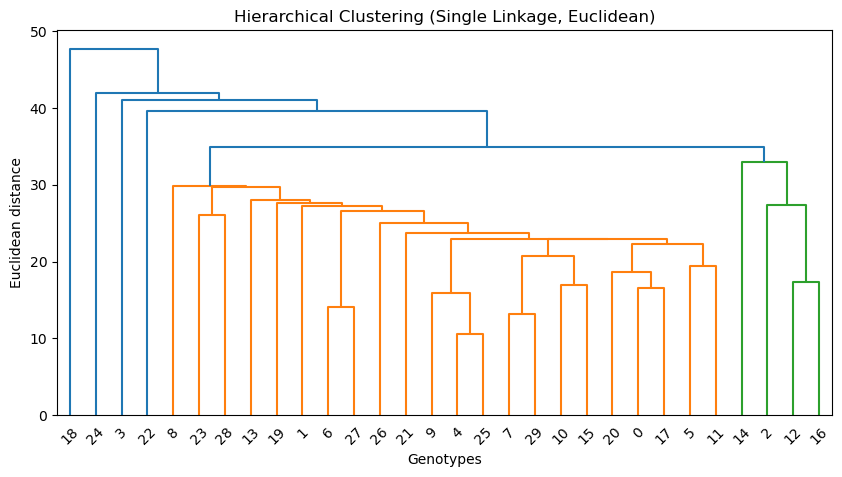

Cluster 1 members:
    Cluster  Genotypes
0         1  IGI-19-23
1         1  IGI-19-24
2         1  IGI-19-25
3         1  IGI-19-26
4         1  IGI-19-27
5         1  IGI-19-28
6         1  IGI-19-29
7         1  IGI-19-30
8         1  IGI-19-31
9         1  IGI-19-32
10        1  IGI-19-33
11        1  IGI-19-34
12        1  IGI-19-35
13        1  IGI-19-36
14        1  IGI-19-37
15        1  IGI-19-38
16        1  IGI-19-39
17        1  IGI-19-40
19        1  IGI-19-42
20        1  IGI-19-43
21        1  IGI-19-44
22        1  IGI-19-45
23        1  IGI-19-46
25        1  IGI-19-48
26        1  IGI-19-49
27        1  IGI-19-50
28        1  IGI-19-51
29        1  IGI-19-52


Cluster 2 members:
    Cluster  Genotypes
24        2  IGI-19-47


Cluster 3 members:
    Cluster  Genotypes
18        3  IGI-19-41




In [7]:
# Perform single linkage clustering
single_linkage = linkage(data, method='single', metric = 'euclidean')

# Plot the dendrogram
plt.figure(figsize=(10, 5))
dendrogram(single_linkage)
plt.title('Hierarchical Clustering (Single Linkage, Euclidean)')
plt.xlabel('Genotypes')
plt.ylabel('Euclidean distance')
plt.show()

# Determine the optimal number of clusters or set a threshold
# You can adjust this based on your analysis or preference
# For demonstration purposes, let's use the maxclust criterion with 3 clusters
num_clusters = 3

# Assign cluster labels using the fcluster function
cluster_labels = fcluster(single_linkage, num_clusters, criterion='maxclust')

# Add dendrogram labels as the first column of the dataset
data_with_labels = pd.concat([pd.DataFrame(cluster_labels, columns=['Cluster']), d], axis=1)

# Group the data by the cluster labels
grouped_data = data_with_labels.groupby('Cluster')

# Print the data grouped by cluster
for label, group in grouped_data:
    print(f"Cluster {label} members:")
    print(group)
    print("\n")

# 2. Complete linkage

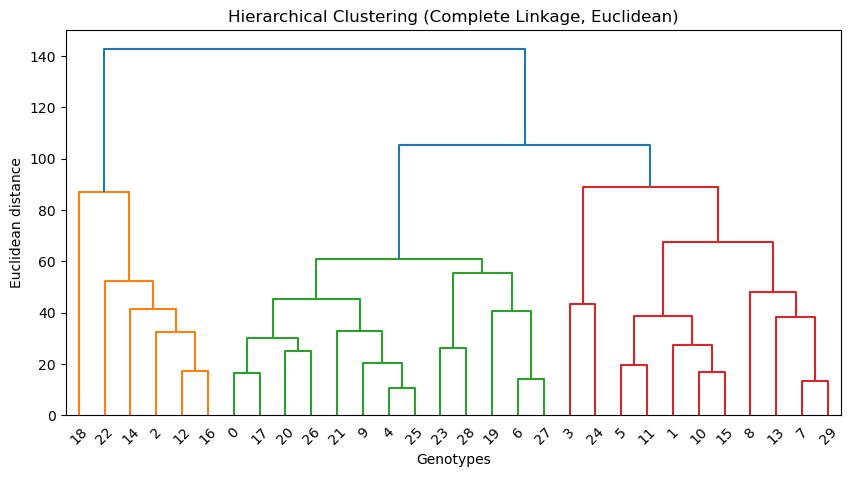

Cluster 1 members:
    Cluster  Genotypes
2         1  IGI-19-25
12        1  IGI-19-35
14        1  IGI-19-37
16        1  IGI-19-39
18        1  IGI-19-41
22        1  IGI-19-45


Cluster 2 members:
    Cluster  Genotypes
0         2  IGI-19-23
4         2  IGI-19-27
6         2  IGI-19-29
9         2  IGI-19-32
17        2  IGI-19-40
19        2  IGI-19-42
20        2  IGI-19-43
21        2  IGI-19-44
23        2  IGI-19-46
25        2  IGI-19-48
26        2  IGI-19-49
27        2  IGI-19-50
28        2  IGI-19-51


Cluster 3 members:
    Cluster  Genotypes
1         3  IGI-19-24
3         3  IGI-19-26
5         3  IGI-19-28
7         3  IGI-19-30
8         3  IGI-19-31
10        3  IGI-19-33
11        3  IGI-19-34
13        3  IGI-19-36
15        3  IGI-19-38
24        3  IGI-19-47
29        3  IGI-19-52




In [8]:
# Perform complete linkage clustering
complete_linkage = linkage(data, method='complete', metric = 'euclidean')

# Plot the dendrogram
plt.figure(figsize=(10, 5))
dendrogram(complete_linkage)
plt.title('Hierarchical Clustering (Complete Linkage, Euclidean)')
plt.xlabel('Genotypes')
plt.ylabel('Euclidean distance')
plt.show()

# Determine the optimal number of clusters or set a threshold
# You can adjust this based on your analysis or preference
# For demonstration purposes, let's use the maxclust criterion with 3 clusters
num_clusters = 3

# Assign cluster labels using the fcluster function
cluster_labels = fcluster(complete_linkage, num_clusters, criterion='maxclust')

# Add dendrogram labels as the first column of the dataset
data_with_labels = pd.concat([pd.DataFrame(cluster_labels, columns=['Cluster']), d], axis=1)

# Group the data by the cluster labels
grouped_data = data_with_labels.groupby('Cluster')

# Print the data grouped by cluster
for label, group in grouped_data:
    print(f"Cluster {label} members:")
    print(group)
    print("\n")

# 3. Average linkage

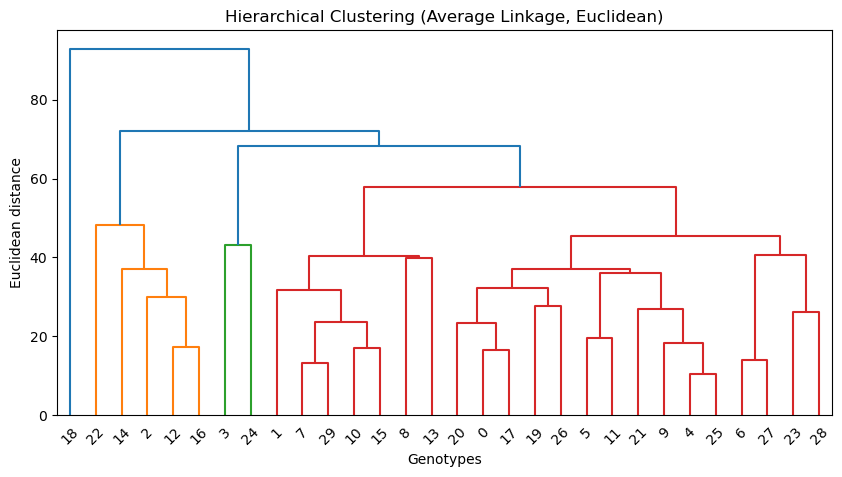

Cluster 1 members:
    Cluster  Genotypes
2         1  IGI-19-25
12        1  IGI-19-35
14        1  IGI-19-37
16        1  IGI-19-39
22        1  IGI-19-45


Cluster 2 members:
    Cluster  Genotypes
3         2  IGI-19-26
24        2  IGI-19-47


Cluster 3 members:
    Cluster  Genotypes
0         3  IGI-19-23
1         3  IGI-19-24
4         3  IGI-19-27
5         3  IGI-19-28
6         3  IGI-19-29
7         3  IGI-19-30
8         3  IGI-19-31
9         3  IGI-19-32
10        3  IGI-19-33
11        3  IGI-19-34
13        3  IGI-19-36
15        3  IGI-19-38
17        3  IGI-19-40
19        3  IGI-19-42
20        3  IGI-19-43
21        3  IGI-19-44
23        3  IGI-19-46
25        3  IGI-19-48
26        3  IGI-19-49
27        3  IGI-19-50
28        3  IGI-19-51
29        3  IGI-19-52


Cluster 4 members:
    Cluster  Genotypes
18        4  IGI-19-41




In [9]:
#  Perform average linkage clustering
average_linkage = linkage(data, method='average', metric = 'euclidean')

# Plot the dendrogram
plt.figure(figsize=(10, 5))
dendrogram(average_linkage)
plt.title('Hierarchical Clustering (Average Linkage, Euclidean)')
plt.xlabel('Genotypes')
plt.ylabel('Euclidean distance')
plt.show() 

# Determine the optimal number of clusters or set a threshold
# You can adjust this based on your analysis or preference
# For demonstration purposes, let's use the maxclust criterion with 4 clusters
num_clusters = 4

# Assign cluster labels using the fcluster function
cluster_labels = fcluster(average_linkage, num_clusters, criterion='maxclust')

# Add dendrogram labels as the first column of the dataset
data_with_labels = pd.concat([pd.DataFrame(cluster_labels, columns=['Cluster']), d], axis=1)

# Group the data by the cluster labels
grouped_data = data_with_labels.groupby('Cluster')

# Print the data grouped by cluster
for label, group in grouped_data:
    print(f"Cluster {label} members:")
    print(group)
    print("\n")

# 4. Centroid Method
Note: Centroid clustering can not be performed using Mahalanobis distance as,
'Centroid' method requires the distance metric to be Euclidean

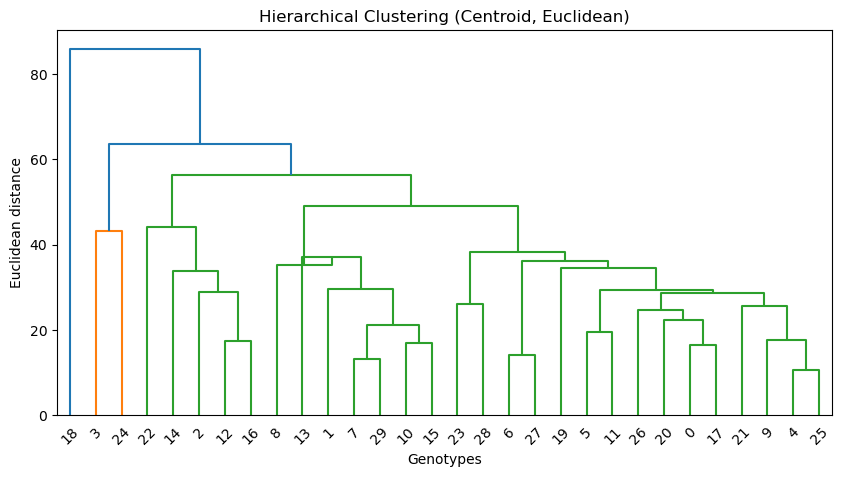

Cluster 1 members:
    Cluster  Genotypes
3         1  IGI-19-26
24        1  IGI-19-47


Cluster 2 members:
    Cluster  Genotypes
0         2  IGI-19-23
1         2  IGI-19-24
2         2  IGI-19-25
4         2  IGI-19-27
5         2  IGI-19-28
6         2  IGI-19-29
7         2  IGI-19-30
8         2  IGI-19-31
9         2  IGI-19-32
10        2  IGI-19-33
11        2  IGI-19-34
12        2  IGI-19-35
13        2  IGI-19-36
14        2  IGI-19-37
15        2  IGI-19-38
16        2  IGI-19-39
17        2  IGI-19-40
19        2  IGI-19-42
20        2  IGI-19-43
21        2  IGI-19-44
22        2  IGI-19-45
23        2  IGI-19-46
25        2  IGI-19-48
26        2  IGI-19-49
27        2  IGI-19-50
28        2  IGI-19-51
29        2  IGI-19-52


Cluster 3 members:
    Cluster  Genotypes
18        3  IGI-19-41




In [10]:
# Perform centroid clustering
centroid = linkage(data, method='centroid', metric='euclidean') 

# Plot the dendrogram
plt.figure(figsize=(10, 5))
dendrogram(centroid)
plt.title('Hierarchical Clustering (Centroid, Euclidean)')
plt.xlabel('Genotypes')
plt.ylabel('Euclidean distance')
plt.show()

# Determine the optimal number of clusters or set a threshold
# You can adjust this based on your analysis or preference
# For demonstration purposes, let's use the maxclust criterion with 3 clusters
num_clusters = 3

# Assign cluster labels using the fcluster function
cluster_labels = fcluster(centroid, num_clusters, criterion='maxclust')

# Add dendrogram labels as the first column of the dataset
data_with_labels = pd.concat([pd.DataFrame(cluster_labels, columns=['Cluster']), d], axis=1)

# Group the data by the cluster labels
grouped_data = data_with_labels.groupby('Cluster')

# Print the data grouped by cluster
for label, group in grouped_data:
    print(f"Cluster {label} members:")
    print(group)
    print("\n")

# 5. Ward's Method

Note: Ward clustering can not be performed using Mahalanobis distance as,
'Ward' method requires the distance metric to be Euclidean

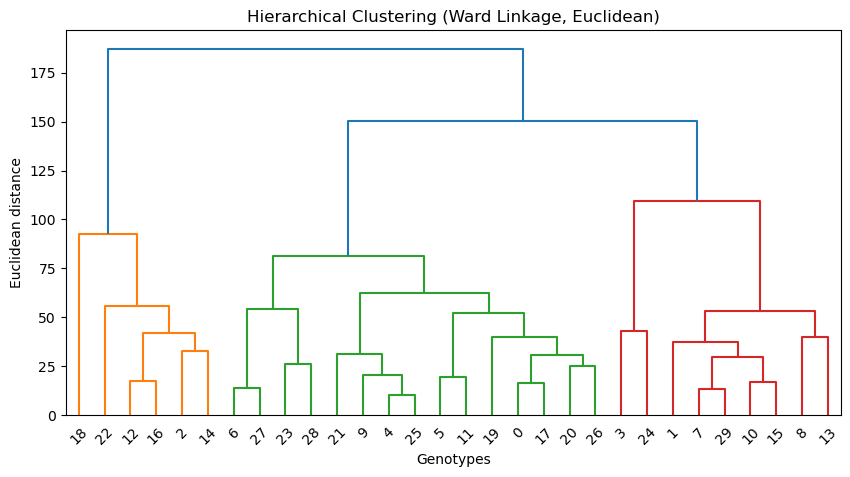

Cluster 1 members:
    Cluster  Genotypes
2         1  IGI-19-25
12        1  IGI-19-35
14        1  IGI-19-37
16        1  IGI-19-39
18        1  IGI-19-41
22        1  IGI-19-45


Cluster 2 members:
    Cluster  Genotypes
0         2  IGI-19-23
4         2  IGI-19-27
5         2  IGI-19-28
6         2  IGI-19-29
9         2  IGI-19-32
11        2  IGI-19-34
17        2  IGI-19-40
19        2  IGI-19-42
20        2  IGI-19-43
21        2  IGI-19-44
23        2  IGI-19-46
25        2  IGI-19-48
26        2  IGI-19-49
27        2  IGI-19-50
28        2  IGI-19-51


Cluster 3 members:
    Cluster  Genotypes
1         3  IGI-19-24
3         3  IGI-19-26
7         3  IGI-19-30
8         3  IGI-19-31
10        3  IGI-19-33
13        3  IGI-19-36
15        3  IGI-19-38
24        3  IGI-19-47
29        3  IGI-19-52




In [11]:
# Perform ward clustering
ward = linkage(data, method='ward', metric='euclidean')

# Plot the dendrogram
plt.figure(figsize=(10, 5))
dendrogram(ward)
plt.title('Hierarchical Clustering (Ward Linkage, Euclidean)')
plt.xlabel('Genotypes')
plt.ylabel('Euclidean distance')
plt.show()

# Determine the optimal number of clusters or set a threshold
# You can adjust this based on your analysis or preference
# For demonstration purposes, let's use the maxclust criterion with 3 clusters
num_clusters = 3

# Assign cluster labels using the fcluster function
cluster_labels = fcluster(ward, num_clusters, criterion='maxclust')

# Add dendrogram labels as the first column of the dataset
data_with_labels = pd.concat([pd.DataFrame(cluster_labels, columns=['Cluster']), d], axis=1)

# Group the data by the cluster labels
grouped_data = data_with_labels.groupby('Cluster')

# Print the data grouped by cluster
for label, group in grouped_data:
    print(f"Cluster {label} members:")
    print(group)
    print("\n")

# 10.3.2 NON-HIERARCHICAL CLUSTERING

# K- Means Clustering

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


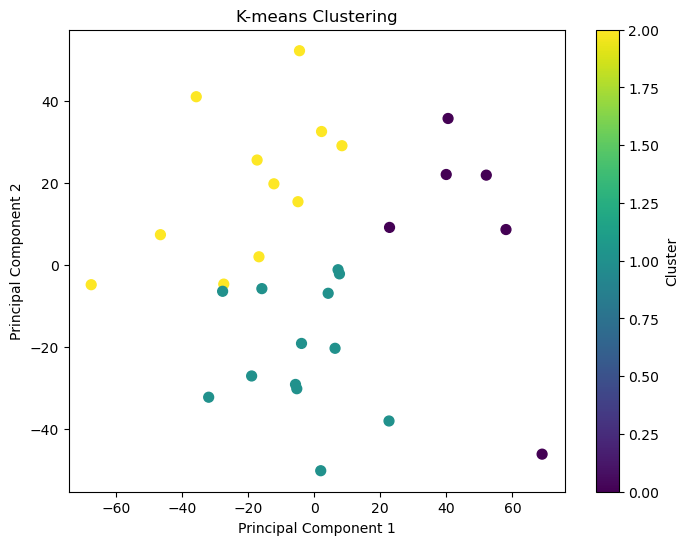

In [12]:
# Perform K-means clustering
kmeans = KMeans(n_clusters=3)  # You can adjust the number of clusters as needed
cluster_labels = kmeans.fit_predict(data)

# Perform PCA to reduce dimensionality to 2 dimensions
pca = PCA(n_components=2)
data_2d = pca.fit_transform(data)

# Plot the clusters
plt.figure(figsize=(8, 6))
plt.scatter(data_2d[:, 0], data_2d[:, 1], c=cluster_labels, cmap='viridis', s=50)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-means Clustering')
plt.colorbar(label='Cluster')
plt.show()

In [13]:
# Add 1 to cluster labels to adjust indexing
cluster_labels_adjusted = cluster_labels + 1

# Add cluster labels as a new column in the dataset
data_with_labels = pd.concat([pd.DataFrame(cluster_labels_adjusted, columns=['Cluster']), d], axis=1)

# Group the data by the adjusted cluster labels
grouped_data = data_with_labels.groupby('Cluster')

# Print the data grouped by cluster
for label, group in grouped_data:
    print(f"Cluster {label} members:")
    print(group)
    print("\n")

Cluster 1 members:
    Cluster  Genotypes
2         1  IGI-19-25
12        1  IGI-19-35
14        1  IGI-19-37
16        1  IGI-19-39
18        1  IGI-19-41
22        1  IGI-19-45


Cluster 2 members:
    Cluster  Genotypes
0         2  IGI-19-23
4         2  IGI-19-27
6         2  IGI-19-29
9         2  IGI-19-32
17        2  IGI-19-40
19        2  IGI-19-42
20        2  IGI-19-43
21        2  IGI-19-44
23        2  IGI-19-46
25        2  IGI-19-48
26        2  IGI-19-49
27        2  IGI-19-50
28        2  IGI-19-51


Cluster 3 members:
    Cluster  Genotypes
1         3  IGI-19-24
3         3  IGI-19-26
5         3  IGI-19-28
7         3  IGI-19-30
8         3  IGI-19-31
10        3  IGI-19-33
11        3  IGI-19-34
13        3  IGI-19-36
15        3  IGI-19-38
24        3  IGI-19-47
29        3  IGI-19-52


